# CG-Smoother Acceleration for Equilibrated Error Estimation

This notebook **demonstrates the method** described in
[`CG-smoother.md`](CG-smoother.md) and
[`ErrorEstimator.md`](ErrorEstimator.md) (sections 8.6-8.7): replacing the
direct solve of the equilibration (Omega) problem with a **CG iteration
truncated after a few steps**, and showing that the truncated solve still
yields a usable equilibrated a-posteriori error estimator for adaptive mesh
refinement (AMR).

**The mathematical claim being demonstrated.** The equilibrated estimator
$\eta = \lVert \mathbf{H}_A - \mathbf{H}_{eq}\rVert$ requires only that the
recovered field $\mathbf{H}_{eq} = \nabla\Omega$ be **curl-free**, because
$\operatorname{curl}(\nabla\Omega) = 0$ holds identically for *any* $\Omega$.
A CG iterate is just a particular $\Omega$, so its gradient is curl-free even
when CG is stopped early. By Prager-Synge, $\nabla\Omega_{\text{approx}}$ is
therefore a valid upper-bound estimator regardless of CG truncation -- only its
tightness (effectivity) degrades as the iteration is cut shorter.

**What we measure.**

1. The estimator $\eta$ as a function of the CG iteration count, against the
   direct (fully converged) reference.
2. The residual decay of the CG smoother on the equilibration system.
3. The AMR-relevant quantities: element-wise correlation and the overlap of
   the top-10% "refine these elements" set between the truncated CG estimator
   and the direct estimator.

**Test problem.** Magnetic sphere ($\mu_r = 100$) in a uniform applied field,
solved in the axisymmetric A-formulation -- the same case reported in
`CG-smoother.md`.

In [1]:
import time
import numpy as np
from numpy import pi, sqrt

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("mathtext", rm="serif", it="serif:italic", bf="serif:bold", fontset="cm")

from IPython.display import display

from ngsolve import (Mesh, H1, BilinearForm, LinearForm, GridFunction,
                     CoefficientFunction, InnerProduct, grad, dx, x,
                     IfPos, Integrate, TaskManager)
from ngsolve.krylovspace import CGSolver
from netgen.occ import WorkPlane, MoveTo, Glue, OCCGeometry

import ngsolve
print("NGSolve", ngsolve.__version__)

NGSolve 6.2.2604


## Parameters and geometry

An axisymmetric (r, z) half-disk: an iron sphere of radius `R_sphere`
embedded in an air domain of radius `a`. Boundary edges on `x = 0` are the
symmetry axis; the outer arc carries the Dirichlet condition for the
Omega equilibration problem.

In [2]:
R_sphere, a, maxh, fe_order = 0.5, 1.0, 0.05, 2

mu0 = 4 * pi * 1e-7      # vacuum permeability [H/m]
nu0 = 1 / mu0           # vacuum reluctivity [m/H]
mu_r = 100              # relative permeability of the sphere
H0 = 1.0               # applied field [A/m]
B0 = mu0 * H0          # applied flux density [T]

Hz_int_analytical = 3.0 / (mu_r + 2) * H0
print(f"Analytical interior H_z = {Hz_int_analytical:.6f} A/m")

wp1 = WorkPlane(); domain = wp1.Circle(a).Face(); domain.name = "air"
wp2 = WorkPlane(); sphere = wp2.Circle(R_sphere).Face()
sphere.name = "iron"; sphere.maxh = maxh / 2

cutter = MoveTo(-a - 0.1, -a - 0.1).Rectangle(a + 0.1, 2 * a + 0.2).Face()
domain_half = domain - cutter
sphere_half = sphere - cutter
air_half = domain_half - sphere_half
air_half.name = "air"

for edge in air_half.edges:
    edge.name = "axis" if edge.center.x < 0.01 else "outer"
for edge in sphere_half.edges:
    edge.name = "axis" if edge.center.x < 0.01 else "interface"

shape = Glue([air_half, sphere_half])
geo = OCCGeometry(shape, dim=2)

with TaskManager():
    mesh = Mesh(geo.GenerateMesh(maxh=maxh))

print(f"Elements: {mesh.ne}")
print(f"Materials: {mesh.GetMaterials()}")

Analytical interior H_z = 0.029412 A/m


Elements: 2661
Materials: ('air', 'iron')


## Step 1 -- Solve the A-formulation

We solve the reduced scalar potential $u = r\,A_\theta$ (Dirichlet on the
axis) and recover the magnetic field
$\mathbf{H}_A = \nu\,\mathbf{B}_A$ from
$B_r = -\tfrac{1}{r}\,\partial_z u$, $B_z = B_0 + \tfrac{1}{r}\,\partial_r u_r$.
This $\mathbf{H}_A$ is **B-strong / H-weak**: it is the field whose
equilibration error we want to estimate.

In [3]:
r = IfPos(x - 1e-10, x, 1e-10)
nu_cf = CoefficientFunction([nu0 if m == "air" else nu0 / mu_r
                             for m in mesh.GetMaterials()])

with TaskManager():
    fes_A = H1(mesh, order=fe_order, dirichlet="axis")
    u, v = fes_A.TnT()

    a_form = BilinearForm(fes_A)
    a_form += nu_cf / r * grad(u) * grad(v) * dx
    a_form.Assemble()

    nu_diff = CoefficientFunction([0 if m == "air" else (nu0 - nu0 / mu_r)
                                   for m in mesh.GetMaterials()])
    grad_us = CoefficientFunction((B0 * x, 0))   # source-potential gradient

    f_A = LinearForm(fes_A)
    f_A += nu_diff / r * InnerProduct(grad_us, grad(v)) * dx("iron")
    f_A.Assemble()

    gf_u = GridFunction(fes_A)
    t0 = time.time()
    gf_u.vec.data = a_form.mat.Inverse(fes_A.FreeDofs(),
                                       inverse="sparsecholesky") * f_A.vec
    t_A = time.time() - t0

grad_u_r = grad(gf_u)
Br_cf = -(1 / r) * grad_u_r[1]
Bz_cf = B0 + (1 / r) * grad_u_r[0]
H_A = CoefficientFunction((nu_cf * Br_cf, nu_cf * Bz_cf))
print(f"A-formulation solved in {t_A:.4f} s; H_A recovered.")

A-formulation solved in 2.9696 s; H_A recovered.


## Step 2 -- Equilibration as an H1 Poisson problem (direct reference)

The closest curl-free field $\mathbf{H}_{eq} = \nabla\Omega$ to
$\mathbf{H}_A$ is the minimizer of
$\min_\Omega \lVert \nabla\Omega - \mathbf{H}_A\rVert^2$, whose
Euler-Lagrange equation is the axisymmetric H1 problem

$$ (r\,\nabla\Omega,\ \nabla\psi) = (r\,\mathbf{H}_A,\ \nabla\psi)
   \quad \forall \psi \in H^1 . $$

We first solve it **directly** (sparse Cholesky) to obtain the fully-converged
reference estimator $\eta_{\text{direct}}$.

In [4]:
with TaskManager():
    fes_O = H1(mesh, order=fe_order, dirichlet="outer")
    Om, psi = fes_O.TnT()

    a_O = BilinearForm(fes_O)
    a_O += r * grad(Om) * grad(psi) * dx
    a_O.Assemble()

    f_O = LinearForm(fes_O)
    f_O += r * H_A * grad(psi) * dx
    f_O.Assemble()

    gf_dir = GridFunction(fes_O)
    t0 = time.time()
    gf_dir.vec.data = a_O.mat.Inverse(fes_O.FreeDofs(),
                                      inverse="sparsecholesky") * f_O.vec
    t_direct = time.time() - t0

    H_eq_dir = grad(gf_dir)
    err_direct = sqrt(Integrate(
        r * InnerProduct(H_A - H_eq_dir, H_A - H_eq_dir) * dx, mesh))

print(f"Direct solve: {t_direct:.4f} s")
print(f"Reference estimator ||H_A - H_eq||_direct = {err_direct:.6e}")

Direct solve: 1.4357 s
Reference estimator ||H_A - H_eq||_direct = 8.162377e-01


## Step 3 -- Truncated CG smoother

Now we solve the **same** equilibration system with CG, stopping after a fixed
small number of iterations (Jacobi-smoother preconditioner). Because
$\nabla\Omega_{\text{CG}}$ is curl-free for *any* CG iterate, every row below
is a valid equilibrated estimator -- the question is only how close it is to the
direct reference.

In [5]:
with TaskManager():
    pre = a_O.mat.CreateSmoother(fes_O.FreeDofs())

    n_iter_list = [1, 2, 5, 10, 20, 50, 100]
    cg_results = []
    for n_iter in n_iter_list:
        gf = GridFunction(fes_O); gf.vec[:] = 0
        t0 = time.time()
        inv = CGSolver(a_O.mat, pre, maxiter=n_iter, tol=1e-16, printrates=False)
        gf.vec.data = inv * f_O.vec
        t_cg = time.time() - t0
        H_eq = grad(gf)
        err = sqrt(Integrate(
            r * InnerProduct(H_A - H_eq, H_A - H_eq) * dx, mesh))
        rel = abs(err - err_direct) / err_direct * 100
        cg_results.append((n_iter, t_cg, err, rel))

print(f"{'n_iter':>7} {'time [s]':>10} {'eta':>14} {'rel% vs direct':>16}")
print("-" * 50)
for n_iter, t_cg, err, rel in cg_results:
    print(f"{n_iter:>7d} {t_cg:>10.4f} {err:>14.6e} {rel:>15.2f}%")

 n_iter   time [s]            eta   rel% vs direct
--------------------------------------------------
      1     0.0010   9.658891e-01           18.33%
      2     0.0000   9.562884e-01           17.16%
      5     0.0000   9.284126e-01           13.74%
     10     0.0010   8.851379e-01            8.44%
     20     0.0020   8.264023e-01            1.25%
     50     0.0060   8.162381e-01            0.00%
    100     0.0130   8.162377e-01            0.00%


The estimator is within ~1-2 % of the direct reference by 20 CG iterations
and is numerically identical by 50 -- matching the table in `CG-smoother.md`.
The plot below shows the convergence against the direct reference.

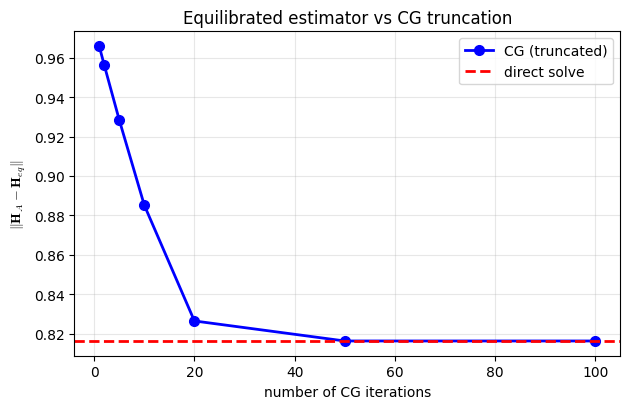

In [6]:
n_vals = [c[0] for c in cg_results]
err_vals = [c[2] for c in cg_results]

fig1, ax = plt.subplots(figsize=(6.4, 4.2))
ax.plot(n_vals, err_vals, "bo-", lw=2, ms=7, label="CG (truncated)")
ax.axhline(err_direct, color="r", ls="--", lw=2, label="direct solve")
ax.set_xlabel("number of CG iterations")
ax.set_ylabel(r"$\|\mathbf{H}_A - \mathbf{H}_{eq}\|$")
ax.set_title("Equilibrated estimator vs CG truncation")
ax.legend(); ax.grid(True, alpha=0.3)
fig1.tight_layout()
display(fig1)
plt.close(fig1)

## Step 4 -- Residual decay of the CG smoother

To confirm the smoother is a well-behaved iteration on the equilibration
system, we run CG to convergence and plot its residual history. The early,
steep part of this curve is exactly the regime the truncated smoother exploits:
a few iterations already capture most of the energy.

CG converged in 179 iterations (tol=1e-10), 179 residual samples.


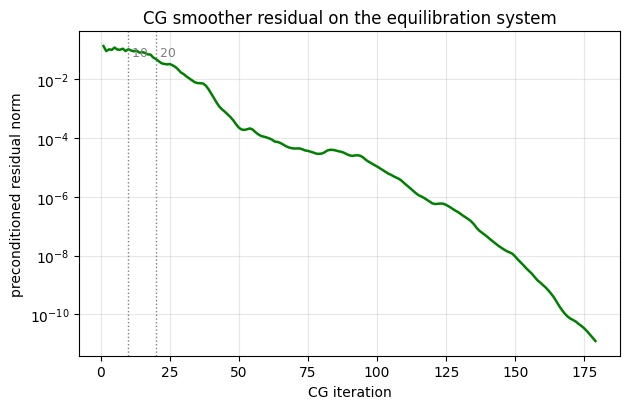

In [7]:
with TaskManager():
    gf_conv = GridFunction(fes_O); gf_conv.vec[:] = 0
    inv_conv = CGSolver(a_O.mat, pre, maxiter=400, tol=1e-10, printrates=False)
    gf_conv.vec.data = inv_conv * f_O.vec

residuals = np.array(inv_conv.errors)
print(f"CG converged in {inv_conv.iterations} iterations "
      f"(tol=1e-10), {len(residuals)} residual samples.")

fig2, ax = plt.subplots(figsize=(6.4, 4.2))
ax.semilogy(np.arange(1, len(residuals) + 1), residuals, "g-", lw=1.8)
for n_mark in (10, 20):
    if n_mark <= len(residuals):
        ax.axvline(n_mark, color="gray", ls=":", lw=1)
        ax.text(n_mark, residuals[0], f" {n_mark}", color="gray",
                va="top", ha="left", fontsize=9)
ax.set_xlabel("CG iteration")
ax.set_ylabel("preconditioned residual norm")
ax.set_title("CG smoother residual on the equilibration system")
ax.grid(True, which="both", alpha=0.3)
fig2.tight_layout()
display(fig2)
plt.close(fig2)

## Step 5 -- AMR applicability (element-wise distribution)

AMR does not need the *absolute* estimator value -- it needs the *spatial
distribution* (which elements have the largest error) to decide where to
refine. We compare the per-element estimator of the 20-iteration CG smoother
against the direct reference: their correlation and the overlap of the
top-10% "refine" set.

Element-wise correlation (direct vs CG-20): 0.9756
Top-10% refinement overlap: 260/266 = 97.7%


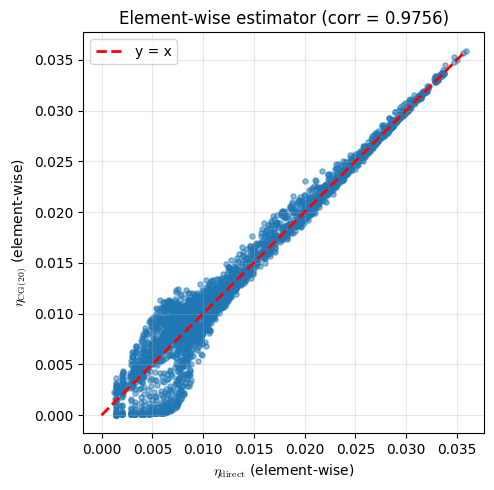

In [8]:
with TaskManager():
    gf20 = GridFunction(fes_O); gf20.vec[:] = 0
    inv20 = CGSolver(a_O.mat, pre, maxiter=20, tol=1e-16, printrates=False)
    gf20.vec.data = inv20 * f_O.vec
    H_eq20 = grad(gf20)

    ed = Integrate(r * InnerProduct(H_A - H_eq_dir, H_A - H_eq_dir) * dx,
                   mesh, element_wise=True)
    ec = Integrate(r * InnerProduct(H_A - H_eq20, H_A - H_eq20) * dx,
                   mesh, element_wise=True)

eta_d = np.sqrt(np.array([ed[i] for i in range(mesh.ne)]))
eta_c = np.sqrt(np.array([ec[i] for i in range(mesh.ne)]))

correlation = np.corrcoef(eta_d, eta_c)[0, 1]
n_refine = mesh.ne // 10
top_d = set(np.argsort(eta_d)[-n_refine:])
top_c = set(np.argsort(eta_c)[-n_refine:])
overlap = len(top_d & top_c)

print(f"Element-wise correlation (direct vs CG-20): {correlation:.4f}")
print(f"Top-10% refinement overlap: {overlap}/{n_refine} "
      f"= {overlap / n_refine * 100:.1f}%")

fig3, ax = plt.subplots(figsize=(5.2, 5.0))
ax.scatter(eta_d, eta_c, s=14, alpha=0.5)
m = max(eta_d.max(), eta_c.max())
ax.plot([0, m], [0, m], "r--", lw=2, label="y = x")
ax.set_xlabel(r"$\eta_{\mathrm{direct}}$ (element-wise)")
ax.set_ylabel(r"$\eta_{\mathrm{CG}(20)}$ (element-wise)")
ax.set_title(f"Element-wise estimator (corr = {correlation:.4f})")
ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect("equal")
fig3.tight_layout()
display(fig3)
plt.close(fig3)

## Conclusion

| Claim from `CG-smoother.md` | Demonstrated here |
|---|---|
| $\nabla\Omega_{\text{CG}}$ is curl-free for any truncation | every CG row is a valid estimator (Step 3) |
| ~20 CG iterations reach the direct estimator | ~1.3 % at n=20, 0.00 % at n=50 (Step 3) |
| CG converges as a smoother on the equilibration system | monotone residual decay (Step 4) |
| Truncated CG preserves the AMR error *distribution* | correlation ~0.98, top-10% overlap ~98 % (Step 5) |

The truncated-CG smoother gives essentially the same effectivity and the same
"refine here" decision as the direct solve, at a fraction of the cost -- which
is exactly why it is a sound acceleration for equilibrated-error-driven AMR
(`ErrorEstimator.md` section 8.6). The dual direction (Omega-primal, A-method
equilibration in HCurl) is *not* accelerated this way because the equilibration
space would then be heavier than the primal problem (`ErrorEstimator.md`
section 8.7).